In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc
import warnings
import pandas as pd
from rouge_score import rouge_scorer
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('evaluation_results.csv')

In [3]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_rouge(row):
    scores = scorer.score(
        prediction=str(row['Response']),
        target=str(row['answer'])
    )
    return pd.Series({
        'ROUGE_1': scores['rouge1'].fmeasure,
        'ROUGE_2': scores['rouge2'].fmeasure,
        'ROUGE_L': scores['rougeL'].fmeasure,
    })

df[['ROUGE_1', 'ROUGE_2', 'ROUGE_L']] = df.apply(compute_rouge, axis=1)

print(df[['ROUGE_1', 'ROUGE_2', 'ROUGE_L']].describe())

          ROUGE_1     ROUGE_2     ROUGE_L
count  501.000000  501.000000  501.000000
mean     0.640548    0.403426    0.622346
std      0.303876    0.374974    0.302213
min      0.000000    0.000000    0.000000
25%      0.500000    0.000000    0.444444
50%      0.666667    0.400000    0.666667
75%      0.929577    0.700000    0.857143
max      1.000000    1.000000    1.000000


In [4]:
df.columns

Index(['context', 'answer', 'supporting_context', 'Response',
       'context_token_count', 'Analysis', 'Aspect', 'EM', 'Token_F1',
       'Token_Precision', 'Token_Recall', 'METEOR', 'BLEU', 'BERTScore_P',
       'BERTScore_R', 'BERTScore_F1', 'LCS', 'Jaccard_Similarity',
       'Hamming_Distance', 'NLI_Precision', 'NLI_Recall', 'NLI_F1',
       'GEval_Precision', 'GEval_Recall', 'GEval_F1', 'Emb_Precision',
       'Emb_Recall', 'Emb_F1', 'Retrieval_Precision', 'Retrieval_Recall',
       'Retrieval_F1', 'Retrieval_TP', 'Retrieval_FP', 'Retrieval_FN',
       'Faithfulness', 'Context_Precision', 'Context_Recall',
       'Answer_Relevance', 'Token_Accuracy', 'Fuzzy_Accuracy',
       'Meaning_Accuracy_LLM', 'Meaning_Accuracy_Emb', 'Is_Error', 'ROUGE_1',
       'ROUGE_2', 'ROUGE_L'],
      dtype='str')

In [5]:
cols = ['context', 'answer', 'supporting_context', 'Response',
       'context_token_count', 'Analysis', 'Aspect', 'EM', 'Token_F1',
       'Token_Precision', 'Token_Recall', 'METEOR', 'BLEU', 'BERTScore_P',
       'BERTScore_R', 'BERTScore_F1', 'Faithfulness', 'Context_Precision', 'Context_Recall',
        'Token_Accuracy', 'Fuzzy_Accuracy',
       'Meaning_Accuracy_LLM', 'Meaning_Accuracy_Emb','ROUGE_1',
       'ROUGE_2', 'ROUGE_L']
# Require context - Faithfulness, Context precision, context recall

In [6]:
df = df[cols]

In [7]:
print(df[(df['Aspect'] == 'Control') & (df['Analysis'] == 'N')])

                                              context  \
40  to users at scale. The client was created by W...   

                      answer  \
40  Jan Koum and Brian Acton   

                                   supporting_context  \
40  to users at scale. The client was created by W...   

                    Response  context_token_count Analysis   Aspect   EM  \
40  Jan Koum and Brian Acton                  6.0        N  Control  1.0   

    Token_F1  Token_Precision  ...  Faithfulness  Context_Precision  \
40       1.0              1.0  ...      0.857143                1.0   

    Context_Recall  Token_Accuracy  Fuzzy_Accuracy  Meaning_Accuracy_LLM  \
40             1.0             1.0             1.0                   1.0   

    Meaning_Accuracy_Emb  ROUGE_1  ROUGE_2  ROUGE_L  
40                   1.0      1.0      1.0      1.0  

[1 rows x 26 columns]


In [8]:
# df.drop(['context','supporting_context','context_token_count'], axis=1, inplace=True)
df.drop(40,axis=0,inplace=True	)
df.shape

(500, 26)

In [9]:
# with pd.option_context('display.max_columns', None, 'display.max_rows', 100, 'display.max_colwidth', None, 'display.width', None):
#     print(df.head(8))

In [10]:
METRICS = df.columns.to_list()[7:]
METRICS

['EM',
 'Token_F1',
 'Token_Precision',
 'Token_Recall',
 'METEOR',
 'BLEU',
 'BERTScore_P',
 'BERTScore_R',
 'BERTScore_F1',
 'Faithfulness',
 'Context_Precision',
 'Context_Recall',
 'Token_Accuracy',
 'Fuzzy_Accuracy',
 'Meaning_Accuracy_LLM',
 'Meaning_Accuracy_Emb',
 'ROUGE_1',
 'ROUGE_2',
 'ROUGE_L']

In [11]:
df[METRICS] = df[METRICS].astype(float)

In [14]:
# Define filter rules per metric
CONTEXT_FILTERED   = {'Faithfulness', 'Context_Precision'}   # exclude null 'context'
SUPPORT_FILTERED   = {'Context_Recall'}                       # exclude null 'supporting_context'

group_keys = ['Aspect', 'Analysis']

## Defining the palate

In [12]:
PALETTE = {"A": "#2ecc71", "N": "#e74c3c"}
BG      = "#0f1117"
CARD    = "#1a1d27"
TEXT    = "#e8eaf0"
ACCENT  = "#6c63ff"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#2a2d3a", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": "#2a2d3a",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "DejaVu Sans",
})


## The data distribution

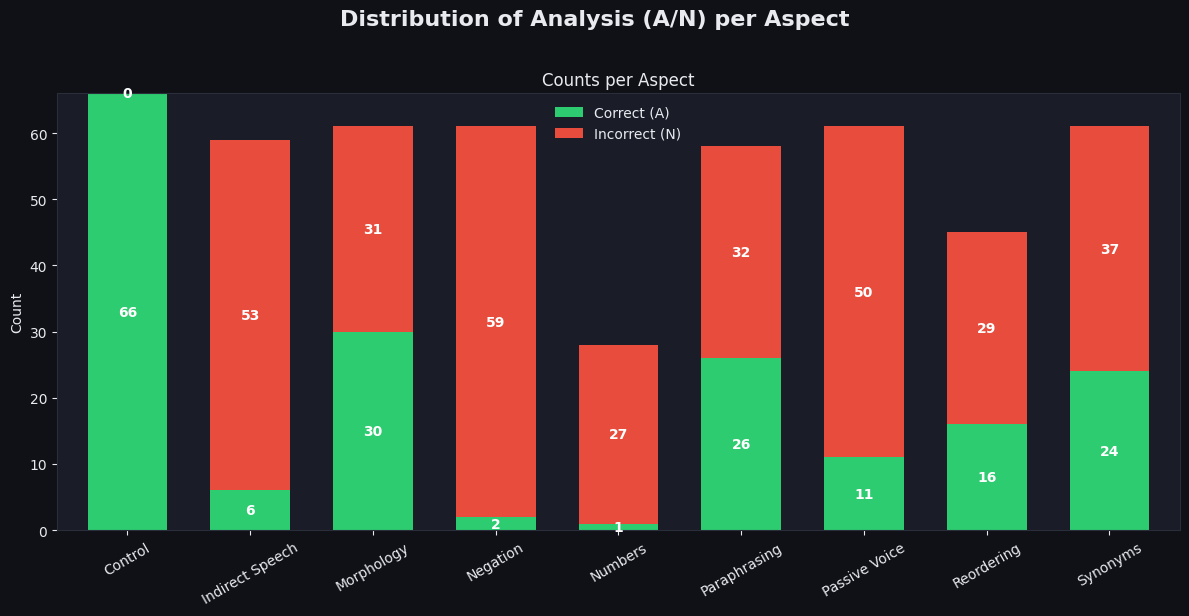

In [13]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)

fig.suptitle(
    "Distribution of Analysis (A/N) per Aspect",
    fontsize=16, color=TEXT, fontweight="bold", y=1.02
)

counts = df.groupby(["Aspect", "Analysis"]).size().unstack(fill_value=0)

# stacked bar chart (counts only)
bars = counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[PALETTE["A"], PALETTE["N"]],
    edgecolor="none",
    width=0.65
)

ax.set_title("Counts per Aspect", color=TEXT)
ax.set_xlabel("")
ax.set_ylabel("Count", color=TEXT)
ax.tick_params(axis="x", rotation=30)

ax.legend(
    ["Correct (A)", "Incorrect (N)"],
    facecolor=CARD,
    edgecolor="none",
    labelcolor=TEXT
)

# ---- add count labels inside bars ----
for container in ax.containers:
    ax.bar_label(container, label_type="center", color="white", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## Per-metric mean

In [15]:
metric_means = {}
for metric in METRICS:
    if metric in CONTEXT_FILTERED:
        subset = df[df['context'].notna()]
    elif metric in SUPPORT_FILTERED:
        subset = df[df['supporting_context'].notna()]
    else:
        subset = df

    metric_means[metric] = subset.groupby(group_keys)[metric].mean()

means = pd.DataFrame(metric_means)

counts = df.groupby(group_keys).size().rename('Count')

tbl = means.join(counts).reset_index()
print(tbl.to_string(index=False))

         Aspect Analysis       EM  Token_F1  Token_Precision  Token_Recall   METEOR     BLEU  BERTScore_P  BERTScore_R  BERTScore_F1  Faithfulness  Context_Precision  Context_Recall  Token_Accuracy  Fuzzy_Accuracy  Meaning_Accuracy_LLM  Meaning_Accuracy_Emb  ROUGE_1  ROUGE_2  ROUGE_L  Count
        Control        A 1.000000  1.000000         1.000000      1.000000 0.862042 0.518907     1.000000     1.000000      1.000000      0.426793                1.0             1.0        1.000000        1.000000              1.000000              1.000000 1.000000 0.787879 1.000000     66
Indirect Speech        A 0.000000  0.672628         0.648292      0.701378 0.652888 0.341718     0.952348     0.921140      0.936362           NaN                NaN             NaN        0.737460        0.760911              0.966667              0.866164 0.705574 0.513504 0.689868      6
Indirect Speech        N 0.000000  0.539458         0.389488      0.988994 0.687971 0.148734     0.878509     0.897565      

## Spearman coefficient for human correlation

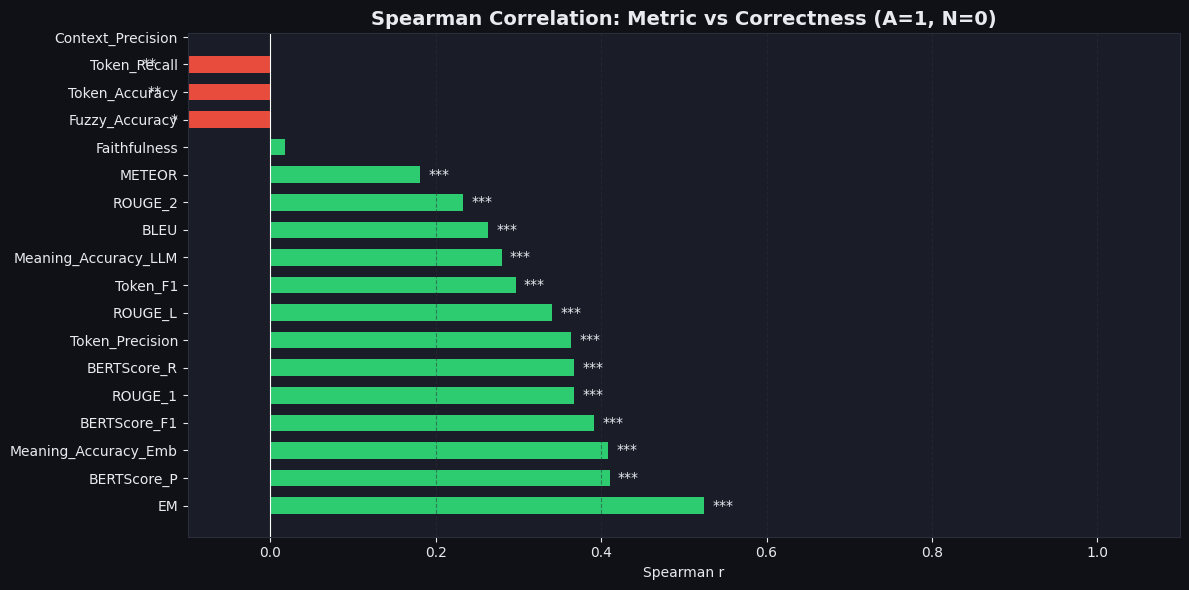


=== SPEARMAN CORRELATIONS ===
              Metric  Spearman_r  p_value
                  EM      0.5244   0.0000
         BERTScore_P      0.4102   0.0000
Meaning_Accuracy_Emb      0.4083   0.0000
        BERTScore_F1      0.3914   0.0000
             ROUGE_1      0.3673   0.0000
         BERTScore_R      0.3671   0.0000
     Token_Precision      0.3634   0.0000
             ROUGE_L      0.3404   0.0000
            Token_F1      0.2965   0.0000
Meaning_Accuracy_LLM      0.2798   0.0000
                BLEU      0.2629   0.0000
             ROUGE_2      0.2331   0.0000
              METEOR      0.1810   0.0000
        Faithfulness      0.0175   0.7230
      Fuzzy_Accuracy     -0.1023   0.0221
      Token_Accuracy     -0.1215   0.0065
        Token_Recall     -0.1280   0.0041
   Context_Precision         NaN      NaN
      Context_Recall         NaN      NaN


In [16]:
df["binary"] = (df["Analysis"] == "A").astype(int)

corrs = {}
pvals = {}
for m in METRICS:
    if m in CONTEXT_FILTERED:
        subset = df[df['context'].notna()]
    elif m in SUPPORT_FILTERED:
        subset = df[df['supporting_context'].notna()]
    else:
        subset = df

    valid = subset[m].notna()
    r, p = stats.spearmanr(subset.loc[valid, m], subset.loc[valid, "binary"])
    corrs[m] = r
    pvals[m] = p

corr_df = pd.DataFrame({"Metric": list(corrs.keys()),
                         "Spearman_r": list(corrs.values()),
                         "p_value": list(pvals.values())})
corr_df = corr_df.sort_values("Spearman_r", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
colors = [PALETTE["A"] if r > 0 else PALETTE["N"] for r in corr_df["Spearman_r"]]
bars = ax.barh(corr_df["Metric"], corr_df["Spearman_r"], color=colors,
               edgecolor="none", height=0.6)
ax.axvline(0, color="white", lw=0.8)
for bar, p in zip(bars, corr_df["p_value"]):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    ax.text(bar.get_width() + 0.01 if bar.get_width() >= 0 else bar.get_width() - 0.01,
            bar.get_y() + bar.get_height()/2,
            sig, va="center", ha="left" if bar.get_width() >= 0 else "right",
            color=TEXT, fontsize=10)
ax.set_title("Spearman Correlation: Metric vs Correctness (A=1, N=0)",
             color=TEXT, fontsize=14, fontweight="bold")
ax.set_xlabel("Spearman r", color=TEXT)
ax.set_xlim(-0.1, 1.1)
ax.grid(axis="x")
plt.tight_layout()
plt.show()

print("\n=== SPEARMAN CORRELATIONS ===")
print(corr_df.round(4).to_string(index=False))

## ROC-AUC curves

### Overall

Saved fig4

=== AUC TABLE ===
              Metric    AUC
         BERTScore_P 0.7461
Meaning_Accuracy_Emb 0.7449
        BERTScore_F1 0.7348
         BERTScore_R 0.7202
             ROUGE_1 0.7190
     Token_Precision 0.7165
             ROUGE_L 0.7033
                  EM 0.6868
            Token_F1 0.6770
                BLEU 0.6574
             ROUGE_2 0.6363
Meaning_Accuracy_LLM 0.6232
              METEOR 0.6085
        Faithfulness 0.5104
   Context_Precision 0.5000
      Context_Recall 0.5000
      Fuzzy_Accuracy 0.4430
      Token_Accuracy 0.4344
        Token_Recall 0.4308


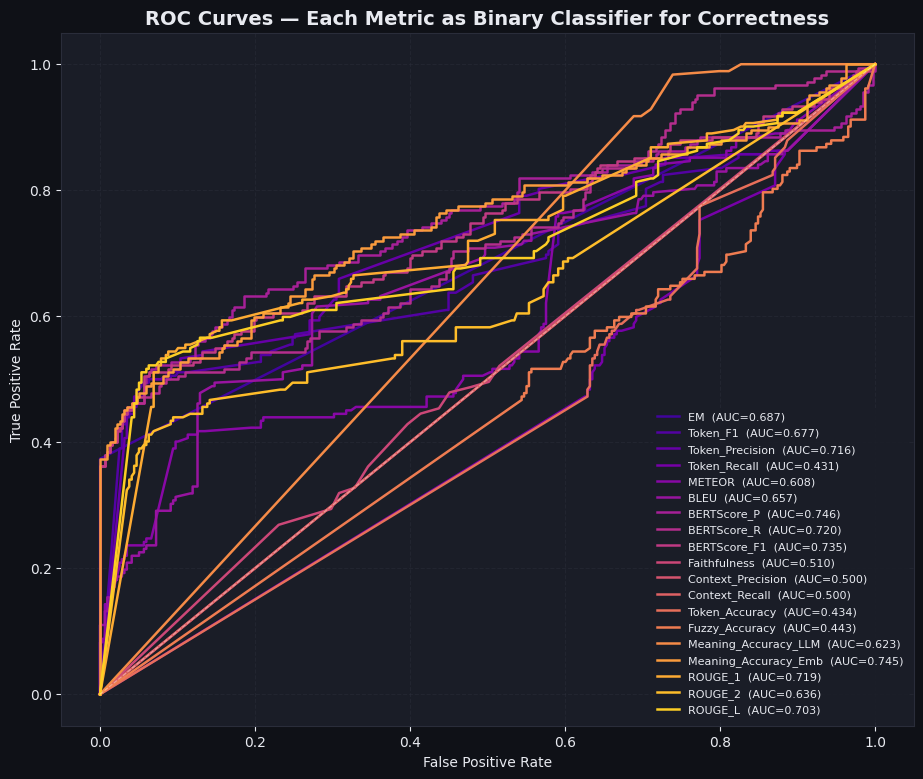

In [17]:
roc_results = {}
fig, ax = plt.subplots(figsize=(11, 9), facecolor=BG)
cmap = plt.cm.plasma
colors_roc = cmap(np.linspace(0.1, 0.9, len(METRICS)))

for (metric, color) in zip(METRICS, colors_roc):
    if metric in CONTEXT_FILTERED:
        subset = df[df['context'].notna()]
    elif metric in SUPPORT_FILTERED:
        subset = df[df['supporting_context'].notna()]
    else:
        subset = df

    valid = subset[[metric, "binary"]].dropna()
    if valid.empty: continue
    fpr, tpr, _ = roc_curve(valid["binary"], valid[metric])
    roc_auc = auc(fpr, tpr)
    roc_results[metric] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{metric}  (AUC={roc_auc:.3f})")

ax.plot([0,1],[0,1], "w--", lw=0.8, alpha=0.4)
ax.set_title("ROC Curves — Each Metric as Binary Classifier for Correctness",
             color=TEXT, fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate", color=TEXT)
ax.set_ylabel("True Positive Rate", color=TEXT)
ax.legend(fontsize=8, facecolor=CARD, edgecolor="none", labelcolor=TEXT,
          loc="lower right", ncol=1)
ax.grid(True)
print("Saved fig4")

auc_df = pd.DataFrame({"Metric": list(roc_results.keys()),
                        "AUC": list(roc_results.values())
                        }).sort_values("AUC", ascending=False)
print("\n=== AUC TABLE ===")
print(auc_df.round(4).to_string(index=False))

### Aspect wise

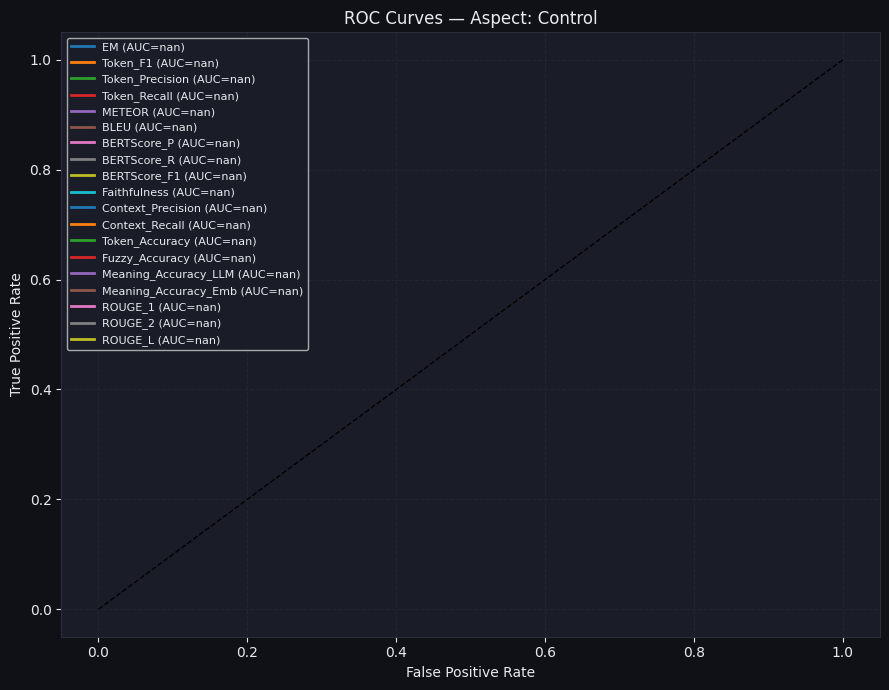

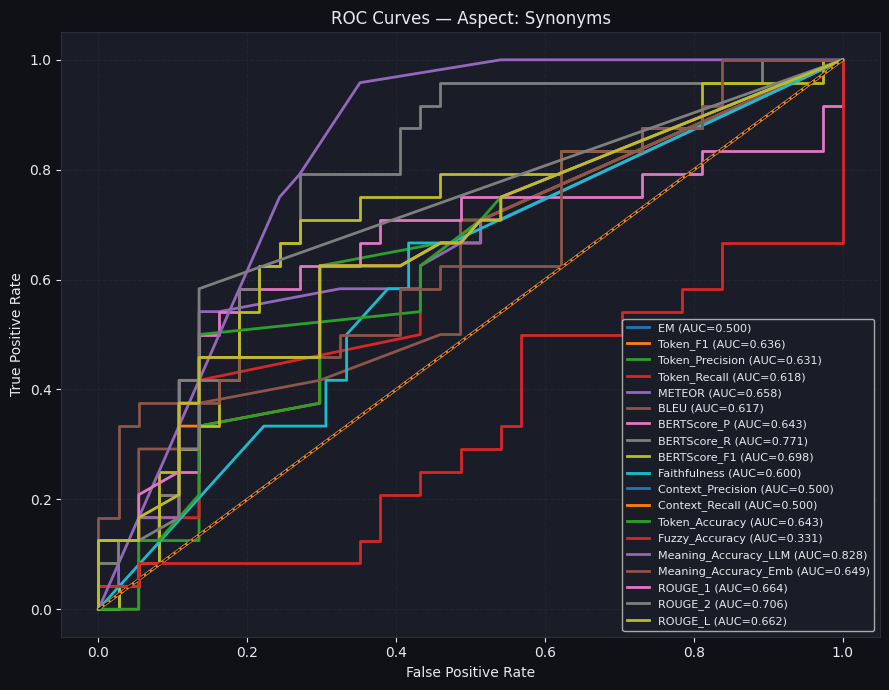

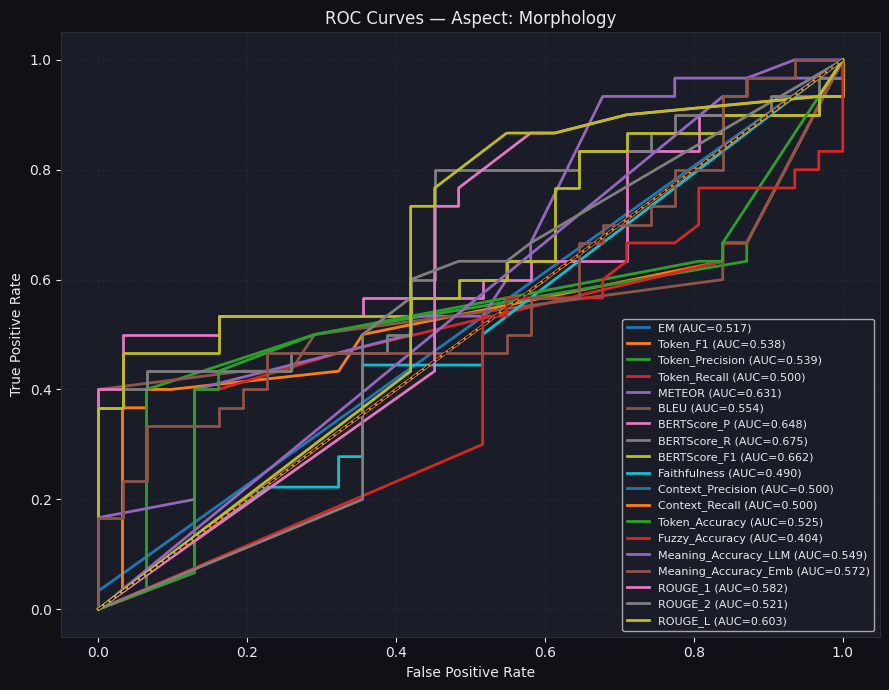

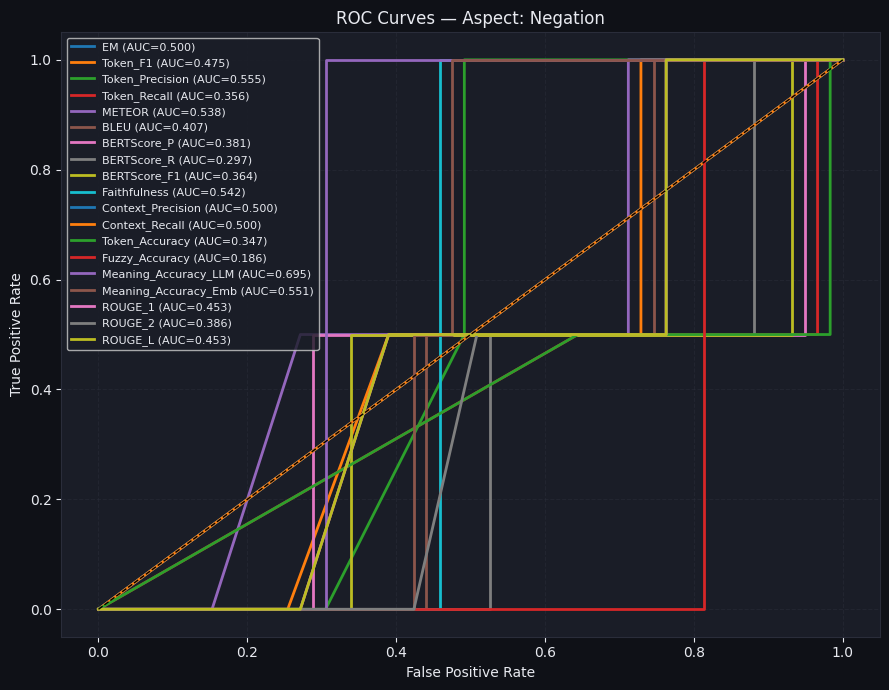

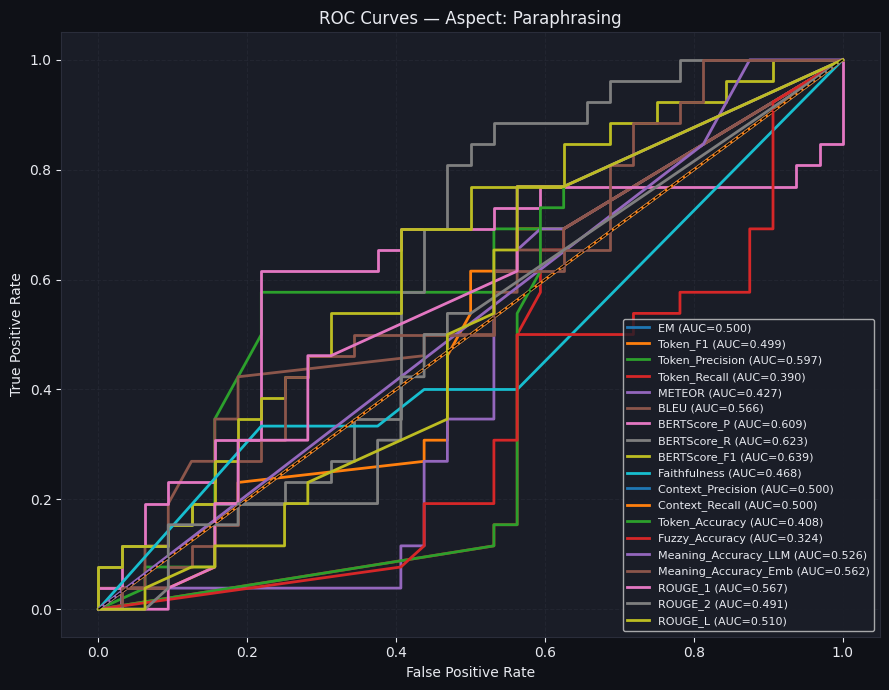

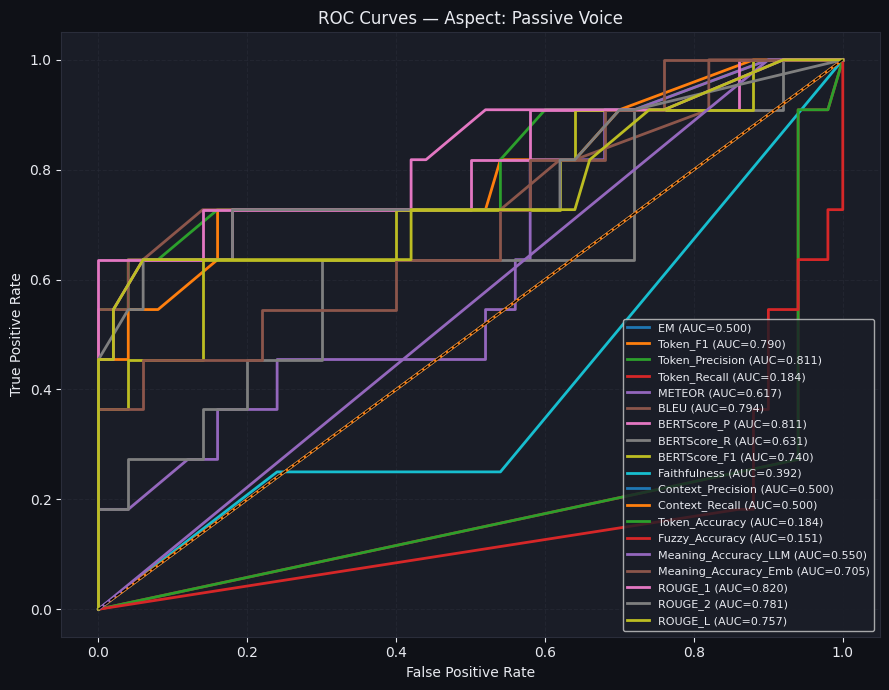

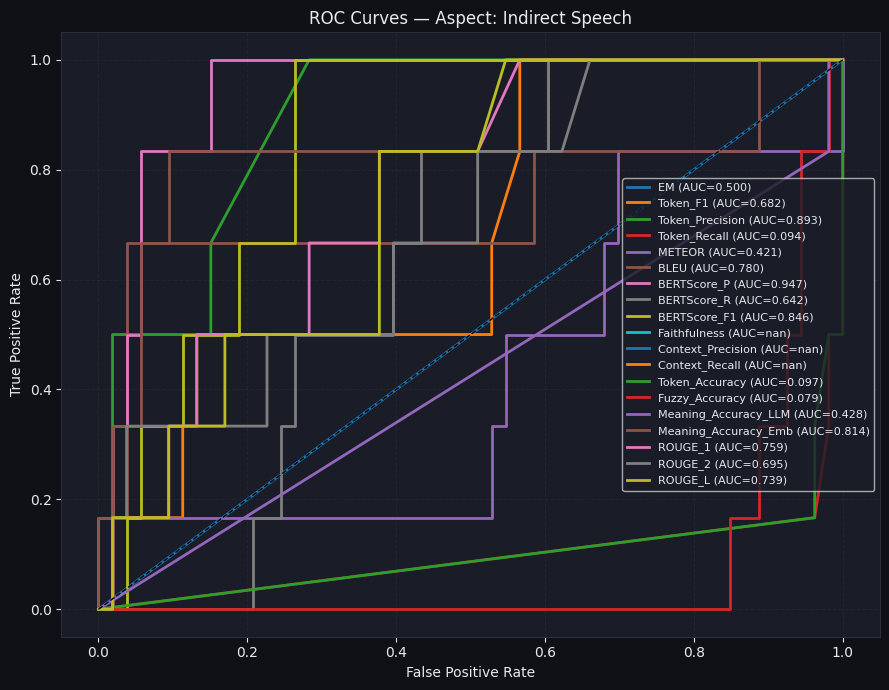

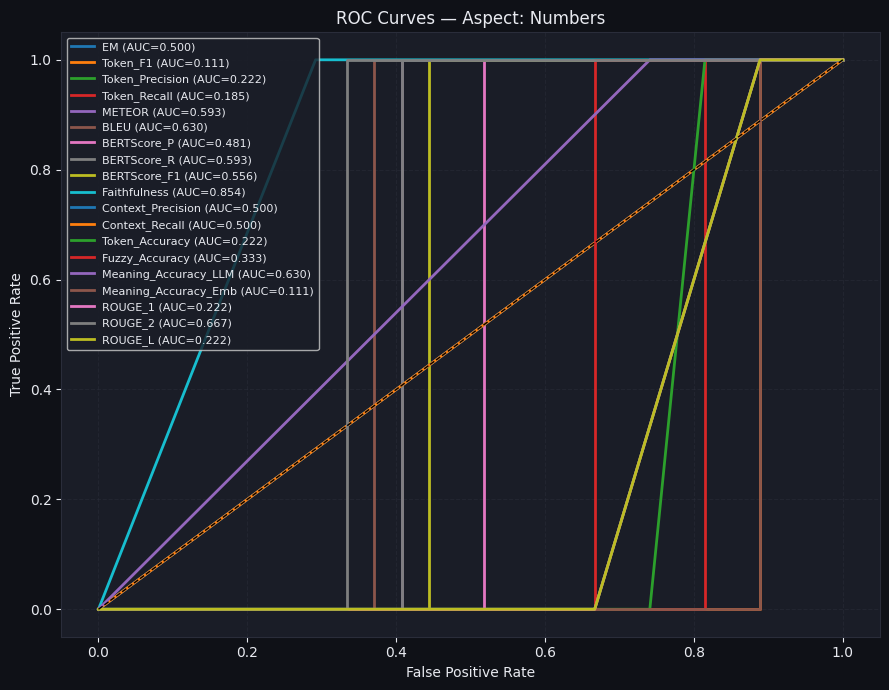

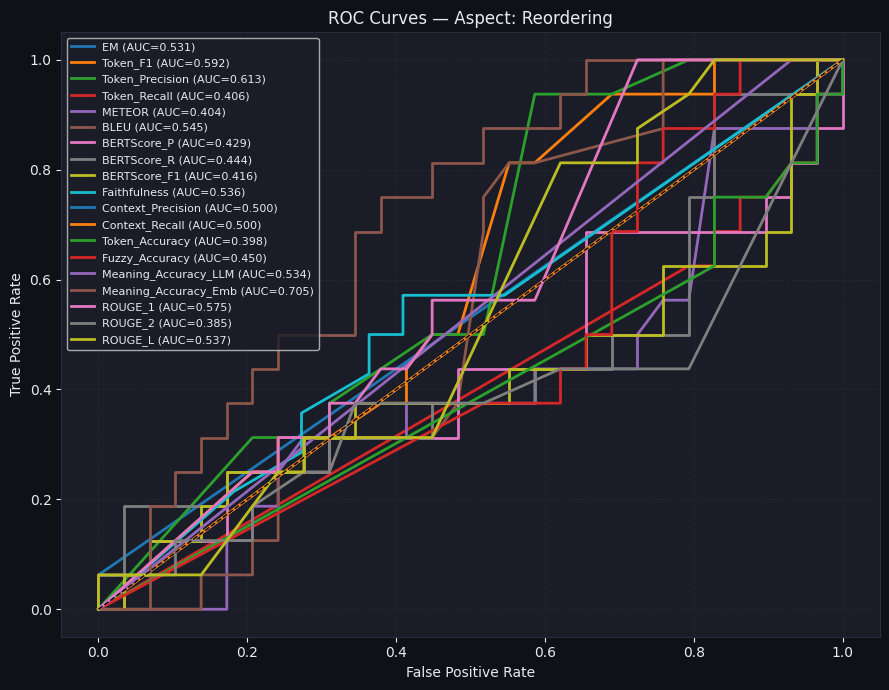

In [20]:
aspects = df["Aspect"].unique()

for aspect in aspects:
    aspect_subset = df[df["Aspect"] == aspect]

    fig, ax = plt.subplots(figsize=(9, 7))

    for metric in METRICS:
        if metric in CONTEXT_FILTERED:
            subset = aspect_subset[aspect_subset['context'].notna()]
        elif metric in SUPPORT_FILTERED:
            subset = aspect_subset[aspect_subset['supporting_context'].notna()]
        else:
            subset = aspect_subset

        valid = subset[[metric, "binary"]].dropna()
        if valid.empty:
            continue

        fpr, tpr, _ = roc_curve(valid["binary"], valid[metric])
        just_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, lw=2, label=f"{metric} (AUC={just_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"ROC Curves — Aspect: {aspect}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

## Aspect Senstivity Score

     Aspect           Metric       ASS  Correct_mean  Incorrect_mean
0  Synonyms               EM  0.000000      0.000000        0.000000
1  Synonyms         Token_F1  0.146980      0.396942        0.249962
2  Synonyms  Token_Precision  0.147954      0.387819        0.239865
3  Synonyms     Token_Recall  0.125119      0.410190        0.285071
4  Synonyms           METEOR  0.187150      0.369949        0.182799
Metric           BERTScore_F1  BERTScore_P  BERTScore_R   BLEU  \
Aspect                                                           
Indirect Speech         0.049        0.074        0.024  0.193   
Morphology              0.022        0.021        0.023  0.243   
Negation                0.014        0.012        0.016  0.109   
Numbers                 0.004        0.001        0.007  0.041   
Paraphrasing            0.027        0.021        0.032  0.021   
Passive Voice           0.036        0.055        0.017  0.340   
Reordering              0.015        0.019        0.010  0

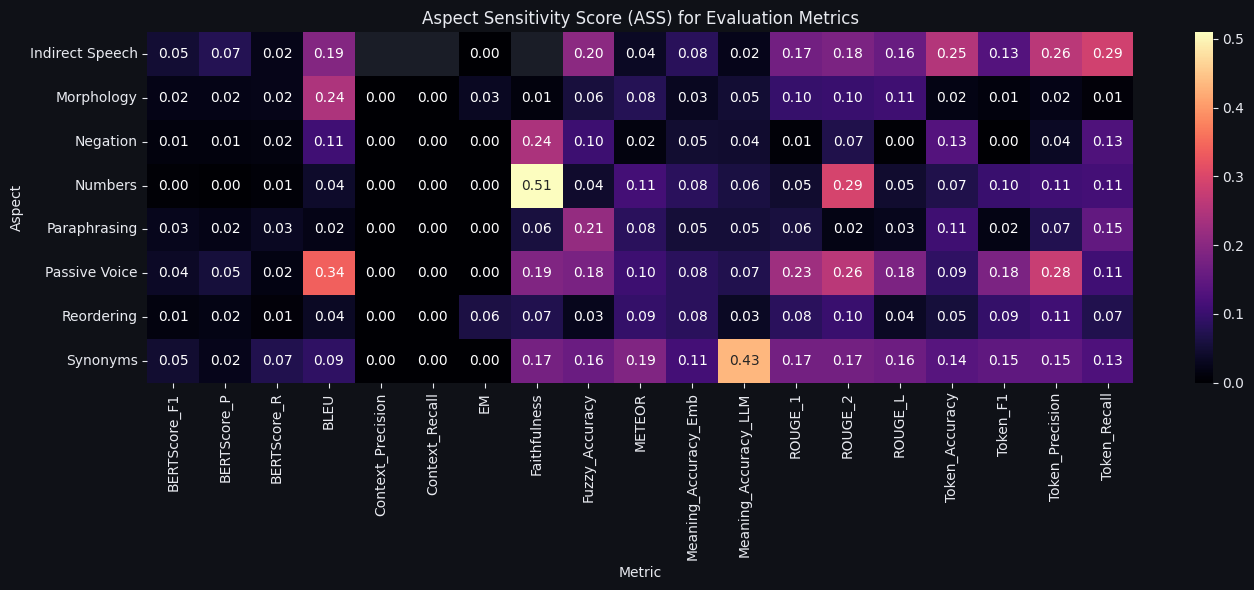

Metric
Faithfulness            0.179711
ROUGE_2                 0.149299
BLEU                    0.133953
Token_Precision         0.128977
Token_Recall            0.123824
Fuzzy_Accuracy          0.123559
ROUGE_1                 0.107545
Token_Accuracy          0.107467
Meaning_Accuracy_LLM    0.096234
ROUGE_L                 0.090578
METEOR                  0.088371
Token_F1                0.086379
Meaning_Accuracy_Emb    0.071475
BERTScore_P             0.028379
BERTScore_F1            0.026575
BERTScore_R             0.024731
EM                      0.011979
Context_Precision       0.000000
Context_Recall          0.000000
Name: ASS, dtype: float64


In [21]:
ass_results = []

for aspect in df["Aspect"].unique():
    aspect_subset = df[df["Aspect"] == aspect]

    for metric in METRICS:
        if metric in CONTEXT_FILTERED:
            subset = aspect_subset[aspect_subset['context'].notna()]
        elif metric in SUPPORT_FILTERED:
            subset = aspect_subset[aspect_subset['supporting_context'].notna()]
        else:
            subset = aspect_subset

        valid = subset[[metric, "binary"]].dropna()
        if valid.empty:
            continue

        correct_scores   = valid[valid["binary"] == 1][metric]
        incorrect_scores = valid[valid["binary"] == 0][metric]

        if len(correct_scores) == 0 or len(incorrect_scores) == 0:
            continue

        correct_mean   = correct_scores.mean()
        incorrect_mean = incorrect_scores.mean()
        ass            = abs(correct_mean - incorrect_mean)

        ass_results.append({
            "Aspect":         aspect,
            "Metric":         metric,
            "ASS":            ass,
            "Correct_mean":   correct_mean,
            "Incorrect_mean": incorrect_mean
        })

ass_df = pd.DataFrame(ass_results)

print(ass_df.head())
ass_pivot = ass_df.pivot(index="Aspect", columns="Metric", values="ASS")
print(ass_pivot.round(3))

plt.figure(figsize=(14, 6))
sns.heatmap(ass_pivot, annot=True, cmap="magma", fmt=".2f")
plt.title("Aspect Sensitivity Score (ASS) for Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Aspect")
plt.tight_layout()
plt.show()

metric_robustness = ass_df.groupby("Metric")["ASS"].mean().sort_values(ascending=False)
print(metric_robustness)

## False-High Rate


=== FALSE-HIGH RATE (N > 0.8) ===
              Metric  FalseHigh_%
   Context_Precision       100.00
      Context_Recall       100.00
        BERTScore_F1        97.17
         BERTScore_P        96.86
         BERTScore_R        95.60
      Fuzzy_Accuracy        72.33
Meaning_Accuracy_LLM        71.07
      Token_Accuracy        67.30
        Token_Recall        67.30
Meaning_Accuracy_Emb        55.03
              METEOR        42.14
        Faithfulness        30.85
             ROUGE_1        16.98
             ROUGE_L        14.47
            Token_F1        11.32
     Token_Precision         9.43
             ROUGE_2         6.92
                BLEU         2.20
                  EM         0.00


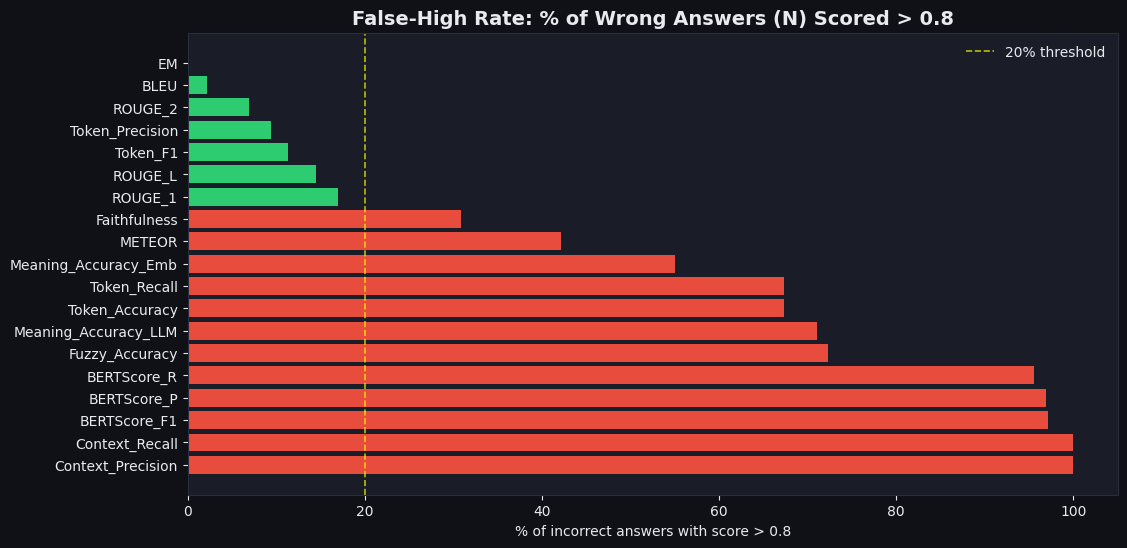

In [ ]:
fh = {}
for m in METRICS:
    if m in CONTEXT_FILTERED:
        wrong = df[(df["Analysis"] == "N") & df['context'].notna()]
    elif m in SUPPORT_FILTERED:
        wrong = df[(df["Analysis"] == "N") & df['supporting_context'].notna()]
    else:
        wrong = df[df["Analysis"] == "N"]

    vals = wrong[m].dropna()
    fh[m] = (vals > 0.8).mean() * 100 if len(vals) else np.nan

fh_df = pd.DataFrame({"Metric": list(fh.keys()),
                       "FalseHigh_%": list(fh.values())
                      }).sort_values("FalseHigh_%", ascending=False)
print("\n=== FALSE-HIGH RATE (N > 0.8) ===")
print(fh_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
colors_fh = [PALETTE["N"] if v > 20 else PALETTE["A"] for v in fh_df["FalseHigh_%"]]
ax.barh(fh_df["Metric"], fh_df["FalseHigh_%"], color=colors_fh, edgecolor="none")
ax.axvline(20, color="yellow", lw=1.2, ls="--", alpha=0.7, label="20% threshold")
ax.set_title("False-High Rate: % of Wrong Answers (N) Scored > 0.8",
             color=TEXT, fontsize=14, fontweight="bold")
ax.set_xlabel("% of incorrect answers with score > 0.8", color=TEXT)
ax.legend(facecolor=CARD, edgecolor="none", labelcolor=TEXT)

## AUC per aspect per metric


=== AUC PER ASPECT PER METRIC ===
                    EM  Token_F1  Token_Precision  Token_Recall  METEOR   BLEU  BERTScore_P  BERTScore_R  BERTScore_F1  Faithfulness  Context_Precision  Context_Recall  Token_Accuracy  Fuzzy_Accuracy  Meaning_Accuracy_LLM  Meaning_Accuracy_Emb  ROUGE_1  ROUGE_2  ROUGE_L
Aspect                                                                                                                                                                                                                                                                        
Synonyms         0.500     0.636            0.631         0.618   0.658  0.617        0.643        0.771         0.698         0.600                0.5             0.5           0.643           0.331                 0.828                 0.649    0.664    0.706    0.662
Morphology       0.517     0.538            0.539         0.500   0.631  0.554        0.648        0.675         0.662         0.490                0.5 

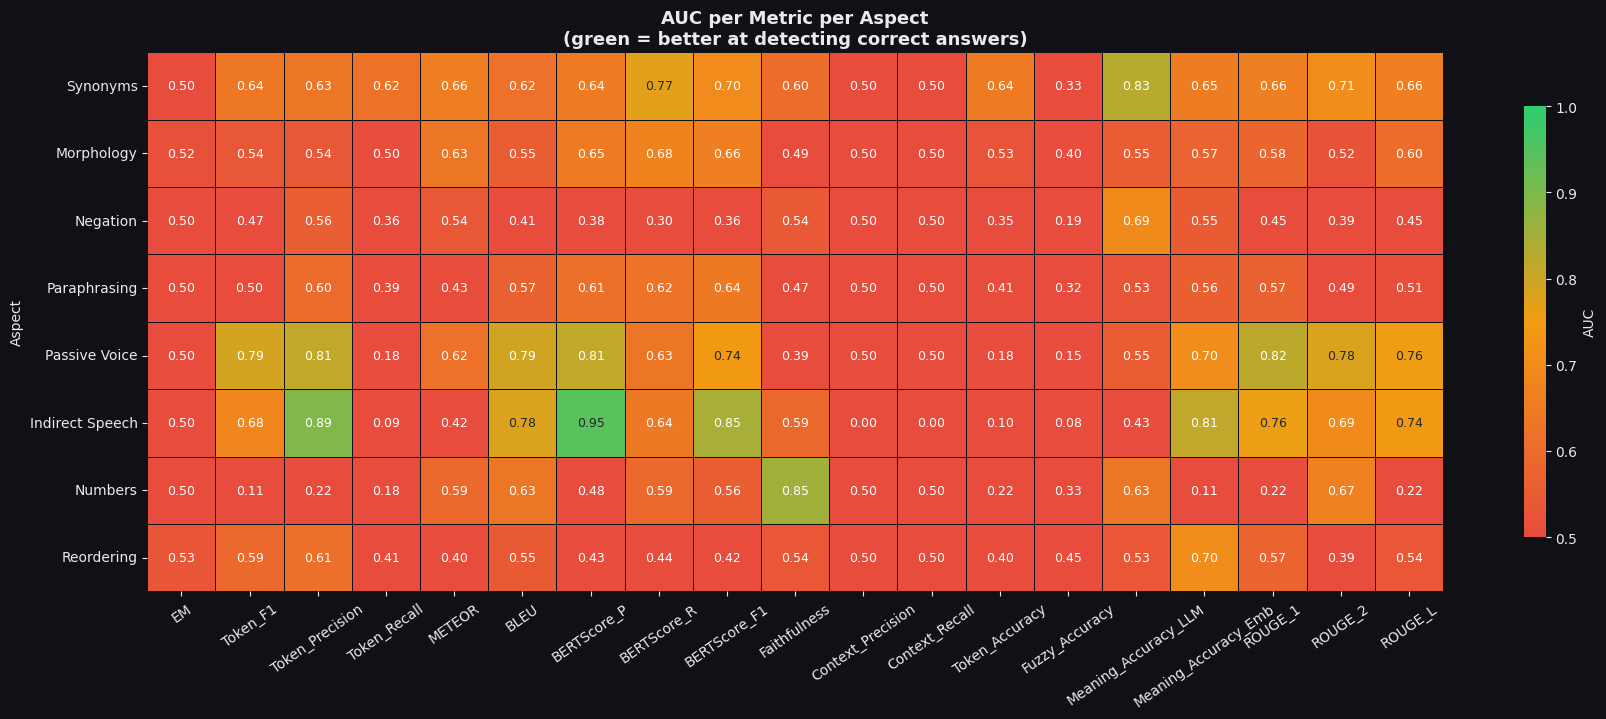

In [36]:
rec_rows = []
for asp in aspects:
    if asp=='Control':
        continue
    aspect_subset = df[df["Aspect"] == asp]
    row = {"Aspect": asp}

    for m in METRICS:
        if m in CONTEXT_FILTERED:
            sub = aspect_subset[aspect_subset['context'].notna()]
        elif m in SUPPORT_FILTERED:
            sub = aspect_subset[aspect_subset['supporting_context'].notna()]
        else:
            sub = aspect_subset

        v = sub[[m, "binary"]].dropna()

        if len(v) < 10:
            row[m] = np.nan
            continue

        if v["binary"].nunique() < 2:
            # Single-class proxy
            only_class = v["binary"].iloc[0]
            mean_score = v[m].mean()
            row[m] = round(1 - mean_score if only_class == 0 else mean_score, 3)
        else:
            fpr, tpr, _ = roc_curve(v["binary"], v[m])
            row[m] = round(auc(fpr, tpr), 3)

    rec_rows.append(row)

rec_df = pd.DataFrame(rec_rows).set_index("Aspect")
print("\n=== AUC PER ASPECT PER METRIC ===")
print(rec_df.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(max(10, len(METRICS)*1.1), 7), facecolor=BG)
cmap_hm = LinearSegmentedColormap.from_list("rg", ["#e74c3c","#f39c12","#2ecc71"])
sns.heatmap(rec_df, annot=True, fmt=".2f", cmap=cmap_hm,
            vmin=0.5, vmax=1.0, ax=ax,
            linewidths=0.4, linecolor="#0f1117",
            cbar_kws={"shrink": 0.8, "label": "AUC"},
            annot_kws={"size": 9})
ax.set_title("AUC per Metric per Aspect\n(green = better at detecting correct answers)",
             color=TEXT, fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

print("\n=== BEST METRIC PER ASPECT (by AUC) ===")
best = rec_df.idxmax(axis=1).reset_index()
best.columns = ["Aspect", "Best_Metric"]
best["AUC"] = [rec_df.loc[row.Aspect, row.Best_Metric] for _, row in best.iterrows()]
print(best.to_string(index=False))


In [31]:
# Show how many valid rows each metric has per aspect
coverage = {}
for asp in aspects:
    aspect_subset = df[df["Aspect"] == asp]
    row = {}
    for m in METRICS:
        if m in CONTEXT_FILTERED:
            sub = aspect_subset[aspect_subset['context'].notna()]
        elif m in SUPPORT_FILTERED:
            sub = aspect_subset[aspect_subset['supporting_context'].notna()]
        else:
            sub = aspect_subset
        row[m] = sub[m].notna().sum()
    coverage[asp] = row

coverage_df = pd.DataFrame(coverage).T
print(coverage_df[["Faithfulness", "Context_Precision", "Context_Recall"]])

                 Faithfulness  Context_Precision  Context_Recall
Control                    54                 54              46
Synonyms                   48                 48              41
Morphology                 49                 49              41
Negation                   49                 49              43
Paraphrasing               47                 47              40
Passive Voice              54                 54              46
Indirect Speech            52                 52              44
Numbers                    25                 25              23
Reordering                 36                 36              30


In [34]:
for m in ["Faithfulness", "Context_Precision", "Context_Recall"]:
    if m in CONTEXT_FILTERED:
        sub = df[(df["Aspect"] == "Indirect Speech") & df["context"].notna()]
    elif m in SUPPORT_FILTERED:
        sub = df[(df["Aspect"] == "Indirect Speech") & df["supporting_context"].notna()]
    
    v = sub[[m, "binary"]].dropna()
    print(f"{m}: n={len(v)}, classes={v['binary'].unique()}, value_counts=\n{v['binary'].value_counts()}\n")

Faithfulness: n=52, classes=[0], value_counts=
binary
0    52
Name: count, dtype: int64

Context_Precision: n=52, classes=[0], value_counts=
binary
0    52
Name: count, dtype: int64

Context_Recall: n=44, classes=[0], value_counts=
binary
0    44
Name: count, dtype: int64

